In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv("loan_data_2007_2014.csv")
print(df.head())

/tmp/ipykernel_4003/2368068912.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("loan_data_2007_2014.csv")


   Unnamed: 0       id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
0           0  1077501    1296599       5000         5000           4975.0   
1           1  1077430    1314167       2500         2500           2500.0   
2           2  1077175    1313524       2400         2400           2400.0   
3           3  1076863    1277178      10000        10000          10000.0   
4           4  1075358    1311748       3000         3000           3000.0   

         term  int_rate  installment grade  ... total_bal_il il_util  \
0   36 months     10.65       162.87     B  ...          NaN     NaN   
1   60 months     15.27        59.83     C  ...          NaN     NaN   
2   36 months     15.96        84.33     C  ...          NaN     NaN   
3   36 months     13.49       339.31     C  ...          NaN     NaN   
4   60 months     12.69        67.79     B  ...          NaN     NaN   

  open_rv_12m open_rv_24m  max_bal_bc all_util total_rev_hi_lim inq_fi  \
0         NaN         Na

In [ ]:
#1. Overview Dataset
print("1. OVERVIEW DATASET")
print(f"\n Shape     : {df.shape}")
print(f" Memory    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\n Tipe data :")
print(df.dtypes.value_counts())
print("\n📋 Info kolom:")
df.info()
print("\n📋 Describe:")
df.describe().T

1. OVERVIEW DATASET

 Shape     : (466285, 75)
 Memory    : 817.8 MB

 Tipe data :
float64    46
object     22
int64       7
Name: count, dtype: int64

📋 Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade 

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,466285.0,2.331420e+05,1.346050e+05,0.00,1.165710e+05,2.331420e+05,3.497130e+05,4.662840e+05
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01


In [ ]:
#drop column 100% null, identity and post credit
df_clean = df.copy()
df_clean = df_clean.drop(columns=[c for c in df_clean.columns if 'Unnamed' in c])
cols_to_drop = [
    'id', 'member_id',
    'funded_amnt', 'funded_amnt_inv',
    'installment',
    'emp_title',
    'url', 'desc', 'title', 'zip_code', 'addr_state',
    'mths_since_last_delinq', 'mths_since_last_record',
    'out_prncp_inv', 'total_pymnt_inv',
    'next_pymnt_d',
    'mths_since_last_major_derog',
    'policy_code', 'application_type',
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'tot_coll_amt', 'tot_cur_bal',
    'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'total_bal_il', 'il_util',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
    'total_rev_hi_lim',
    'inq_fi', 'total_cu_tl', 'inq_last_12m'
]
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
print("Jumlah kolom setelah drop:", df_clean.shape[1])

Jumlah kolom setelah drop: 35


In [ ]:
# CONVERT DATETIME
date_columns = [
    'issue_d',
    'last_pymnt_d',
    'earliest_cr_line',
    'last_credit_pull_d'
]
for col in date_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], format='%b-%y', errors='coerce')

# FEATURE ENGINEERING
# Payment time
df_clean['payment_time'] = (
    (df_clean['last_pymnt_d'].dt.year - df_clean['issue_d'].dt.year) * 12 +
    (df_clean['last_pymnt_d'].dt.month - df_clean['issue_d'].dt.month)
)
# Credit history length
df_clean['credit_history_length'] = (
    (df_clean['last_credit_pull_d'].dt.year - df_clean['earliest_cr_line'].dt.year) * 12 +
    (df_clean['last_credit_pull_d'].dt.month - df_clean['earliest_cr_line'].dt.month)
)
# HANDLE NILAI NEGATIF
df_clean['payment_time'] = df_clean['payment_time'].clip(lower=0)
df_clean['credit_history_length'] = df_clean['credit_history_length'].clip(lower=0)

print("\nJumlah kolom final:", df_clean.shape[1])
print("\nPreview fitur waktu:")
print(df_clean[['issue_d', 'last_pymnt_d', 'payment_time']].head())
print(df_clean[['earliest_cr_line', 'last_credit_pull_d', 'credit_history_length']].head())



Jumlah kolom final: 37

Preview fitur waktu:
     issue_d last_pymnt_d  payment_time
0 2011-12-01   2015-01-01          37.0
1 2011-12-01   2013-04-01          16.0
2 2011-12-01   2014-06-01          30.0
3 2011-12-01   2015-01-01          37.0
4 2011-12-01   2016-01-01          49.0
  earliest_cr_line last_credit_pull_d  credit_history_length
0       1985-01-01         2016-01-01                  372.0
1       1999-04-01         2013-09-01                  173.0
2       2001-11-01         2016-01-01                  170.0
3       1996-02-01         2015-01-01                  227.0
4       1996-01-01         2016-01-01                  240.0


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 37 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   loan_amnt                   466285 non-null  int64         
 1   term                        466285 non-null  object        
 2   int_rate                    466285 non-null  float64       
 3   grade                       466285 non-null  object        
 4   sub_grade                   466285 non-null  object        
 5   emp_length                  445277 non-null  object        
 6   home_ownership              466285 non-null  object        
 7   annual_inc                  466281 non-null  float64       
 8   verification_status         466285 non-null  object        
 9   issue_d                     466285 non-null  datetime64[ns]
 10  loan_status                 466285 non-null  object        
 11  pymnt_plan                  466285 non-

In [ ]:
print("\n" + "=" * 60)
print("STEP 0: TARGET BINARY")
print("=" * 60)

# mapping ke binary
loan_status_mapping = {
    'Fully Paid': 1,
    'Charged Off': 0,
    'Default': 0,
    'Late (31-120 days)': 0
}
df_clean['target'] = df_clean['loan_status'].map(loan_status_mapping)
df_clean = df_clean.dropna(subset=['target'])
print("Distribusi Target:")
print(df_clean['target'].value_counts())



STEP 0: TARGET BINARY
Distribusi Target:
target
1.0    184739
0.0     50207
Name: count, dtype: int64



UNIVARIATE - NUMERICAL


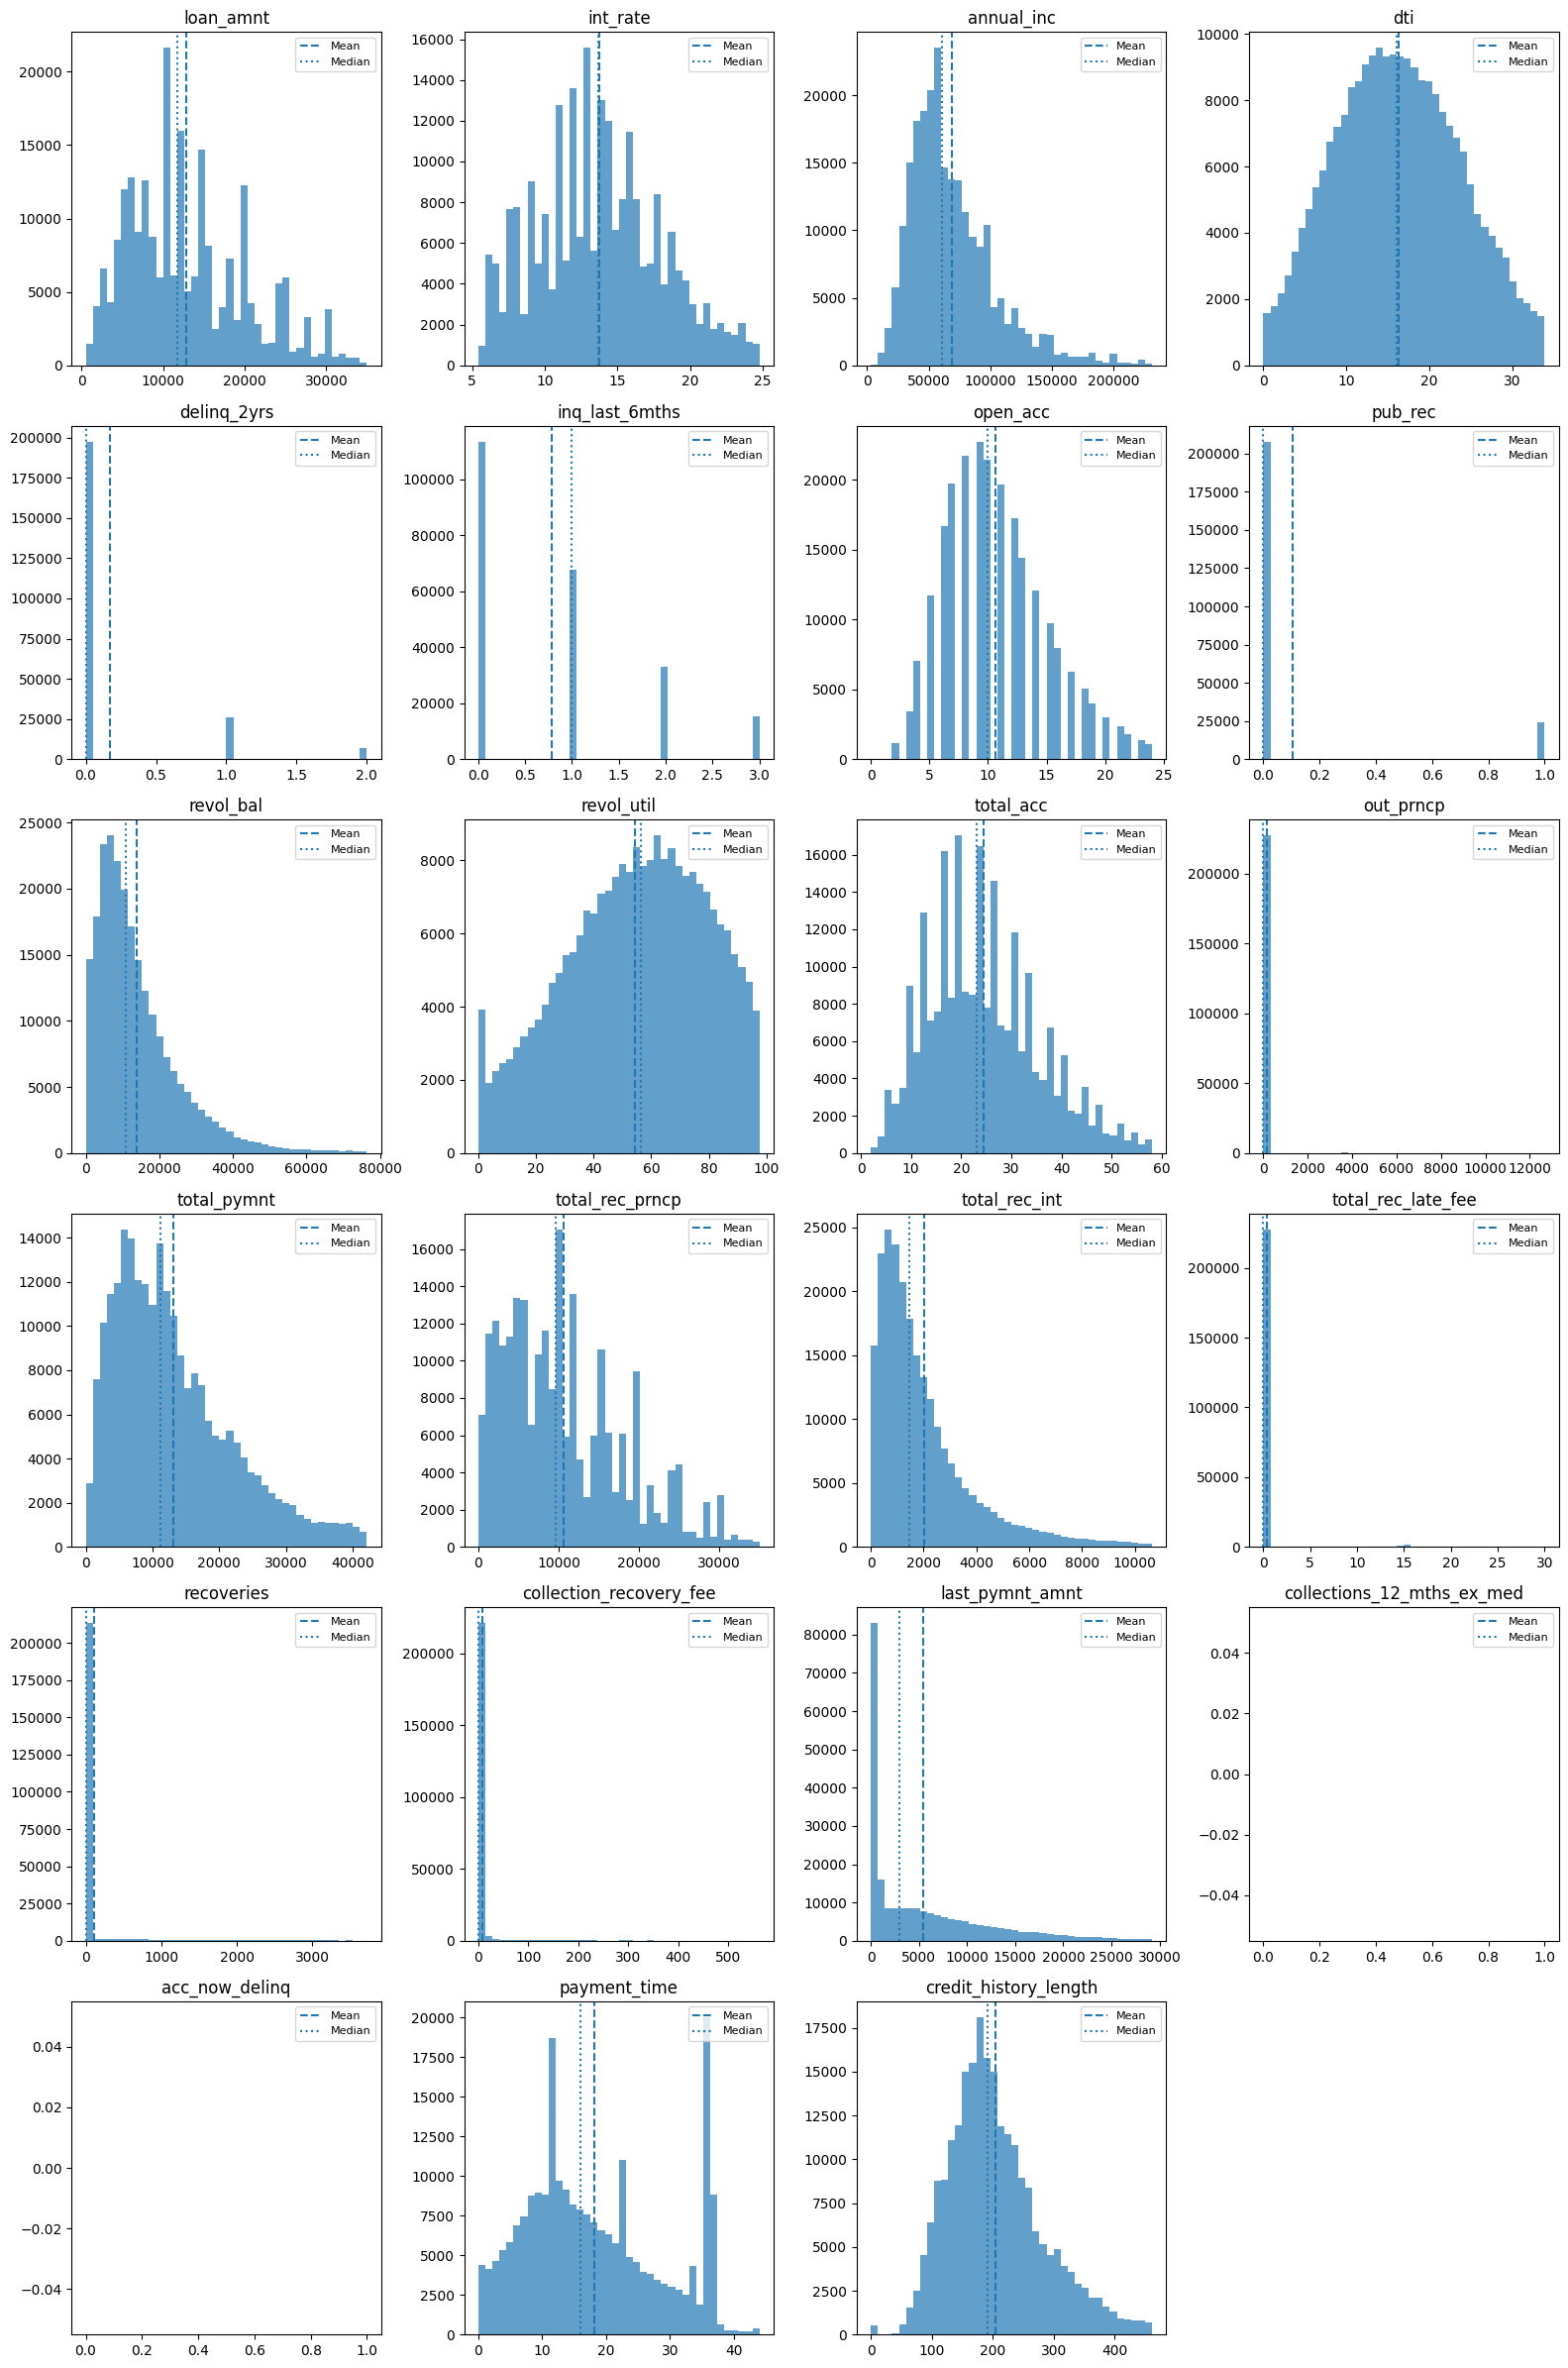

In [ ]:
print("\n" + "=" * 60)
print("UNIVARIATE - NUMERICAL")
print("=" * 60)

num_features = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()
num_features.remove('target')
n_cols = 4
n_rows = int(np.ceil(len(num_features)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    data = df_clean[col].dropna()

    # cap outlier
    data = data[data < data.quantile(0.99)]

    ax.hist(data, bins=40, alpha=0.7)
    ax.axvline(data.mean(), linestyle='--', label='Mean')
    ax.axvline(data.median(), linestyle=':', label='Median')

    ax.set_title(col)
    ax.legend(fontsize=8)

for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



UNIVARIATE - CATEGORICAL


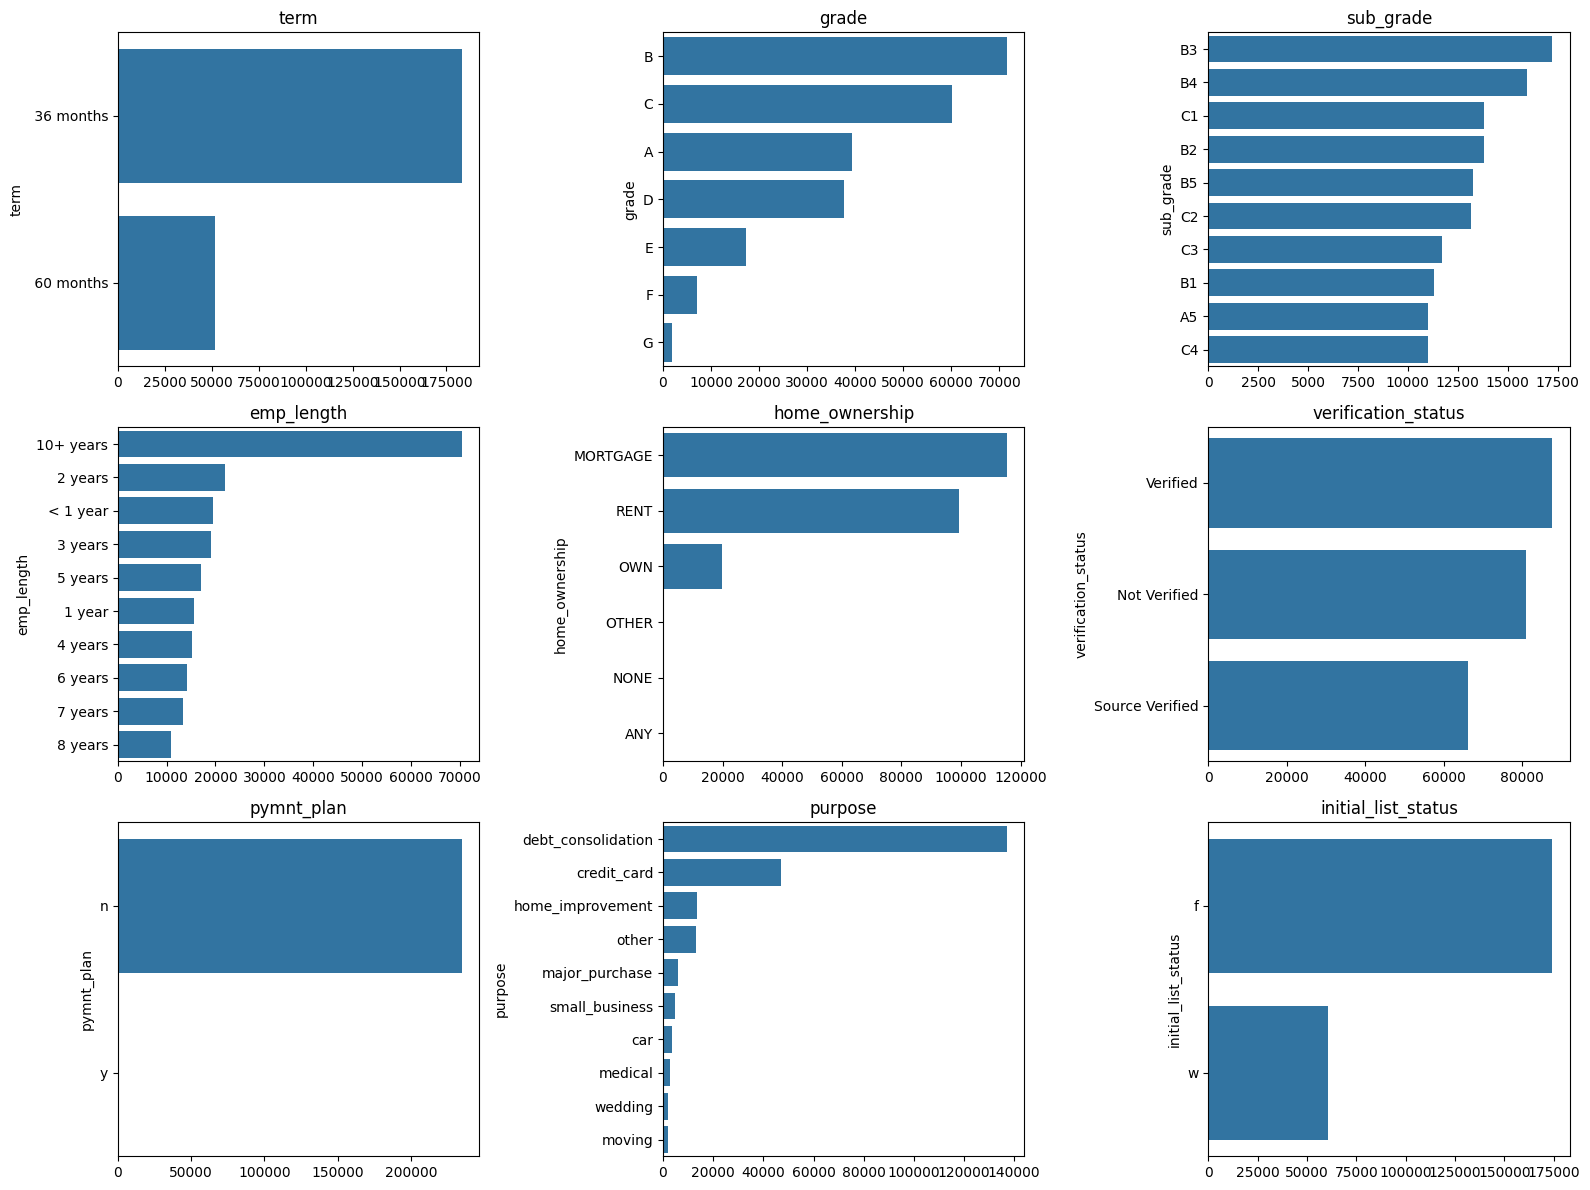

In [ ]:
print("\n" + "=" * 60)
print("UNIVARIATE - CATEGORICAL")
print("=" * 60)

cat_features = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_features = [c for c in cat_features if c != 'loan_status']

n_cols = 3
n_rows = int(np.ceil(len(cat_features)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    vc = df_clean[col].value_counts().head(10)
    sns.barplot(x=vc.values, y=vc.index, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(cat_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



TARGET DISTRIBUTION


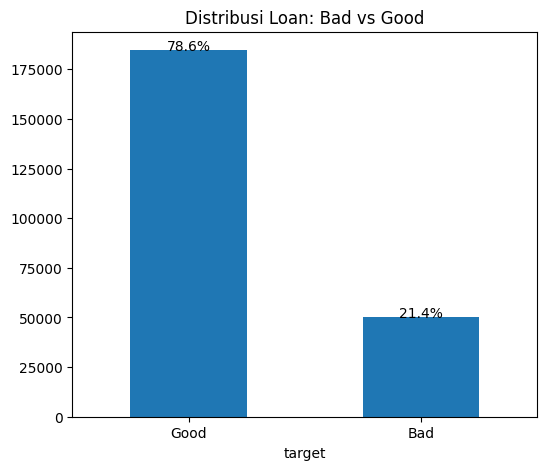

In [ ]:
print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

vc = df_clean['target'].value_counts().rename(index={0:'Bad', 1:'Good'})

plt.figure(figsize=(6,5))
ax = vc.plot(kind='bar')

plt.title('Distribusi Loan: Bad vs Good')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height()/len(df_clean)*100:.1f}%',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center')

plt.show()


BIVARIATE - NUMERICAL vs TARGET


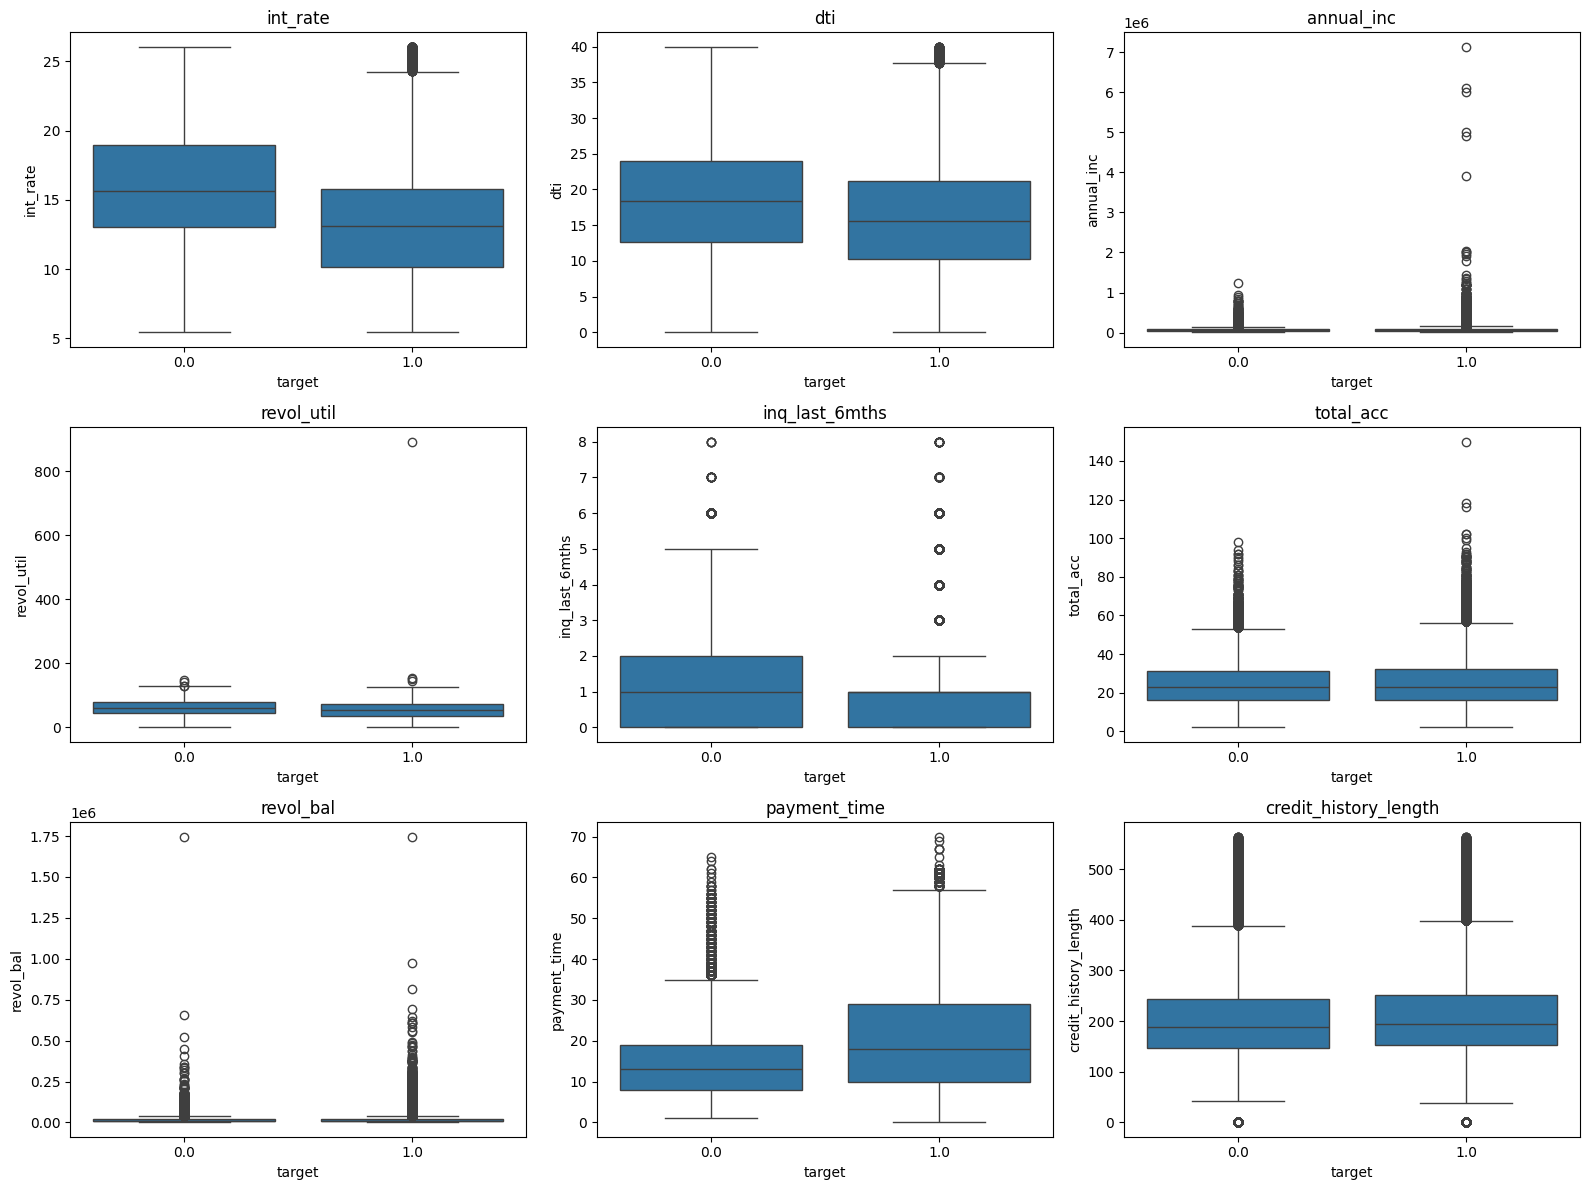

In [ ]:
print("\n" + "=" * 60)
print("BIVARIATE - NUMERICAL vs TARGET")
print("=" * 60)

selected_num = [
    'int_rate', 'dti', 'annual_inc',
    'revol_util', 'inq_last_6mths',
    'total_acc', 'revol_bal',
    'payment_time', 'credit_history_length'
]

selected_num = [c for c in selected_num if c in df_clean.columns]
n_cols = 3
n_rows = int(np.ceil(len(selected_num)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(selected_num):
    sns.boxplot(x='target', y=col, data=df_clean, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(selected_num), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



BIVARIATE - CATEGORICAL vs TARGET


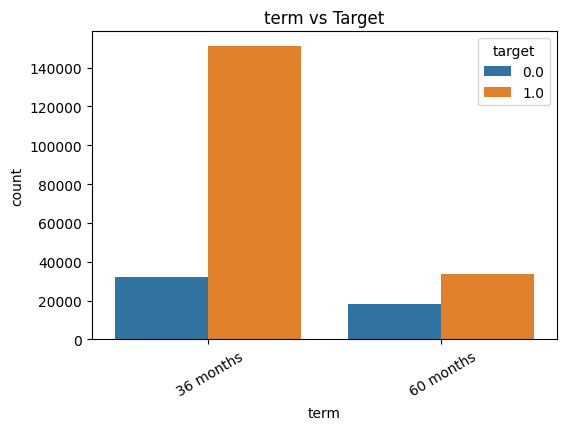

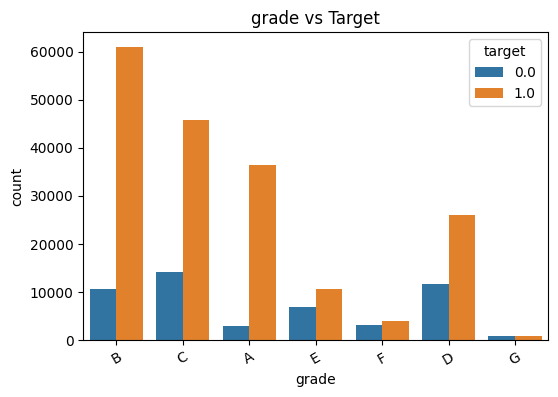

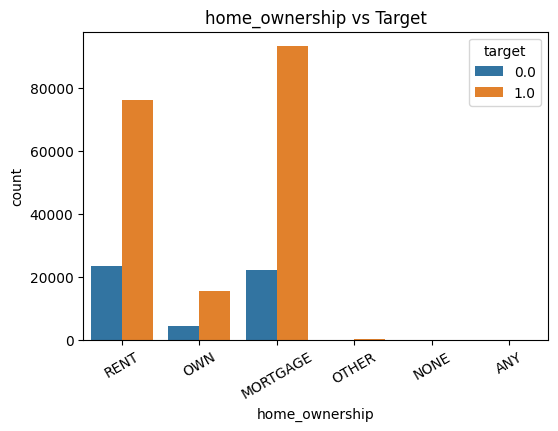

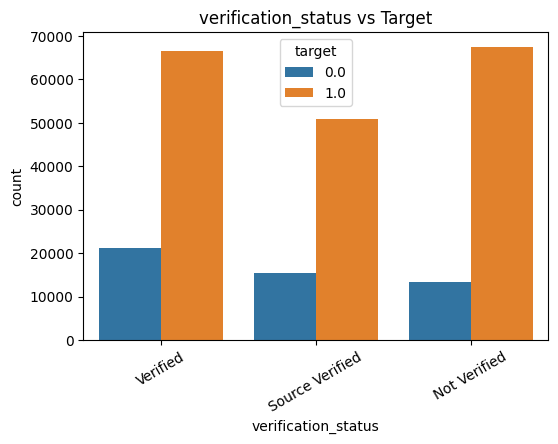

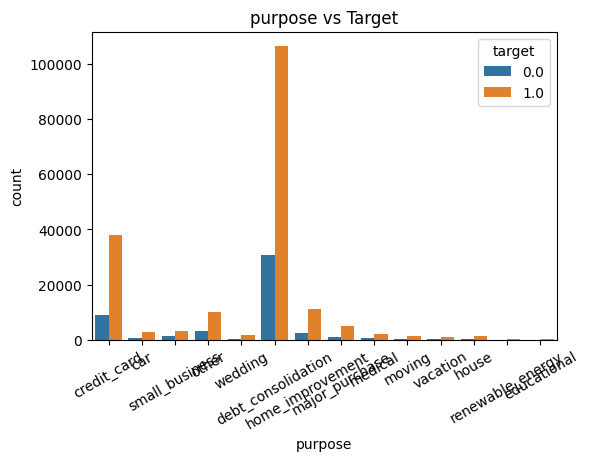

In [ ]:
print("\n" + "=" * 60)
print("BIVARIATE - CATEGORICAL vs TARGET")
print("=" * 60)

selected_cat = [
    'term', 'grade', 'home_ownership',
    'verification_status', 'purpose'
]
selected_cat = [c for c in selected_cat if c in df_clean.columns]

for col in selected_cat:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_clean, x=col, hue='target')
    plt.title(f'{col} vs Target')
    plt.xticks(rotation=30)
    plt.show()


CORRELATION HEATMAP


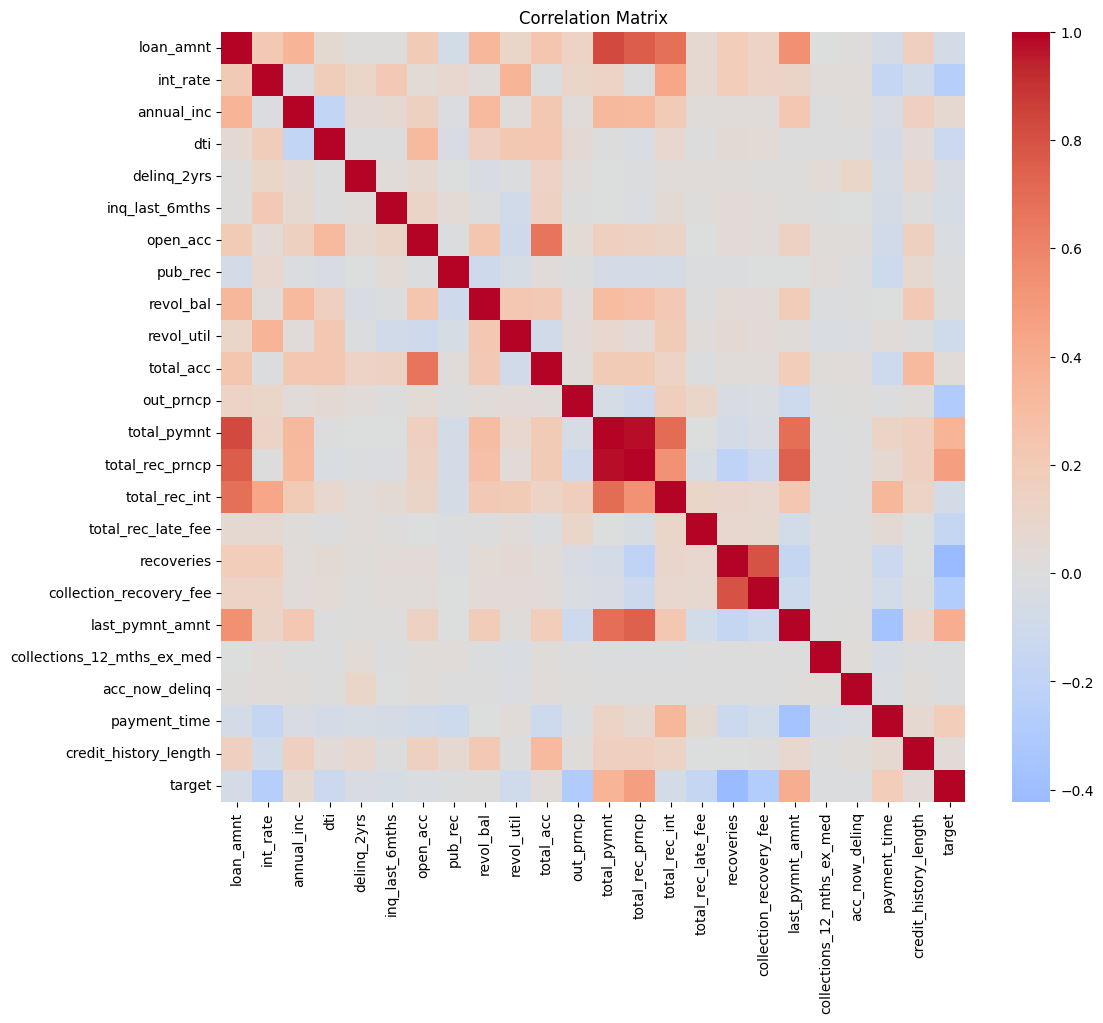

In [ ]:
print("\n" + "=" * 60)
print("CORRELATION HEATMAP")
print("=" * 60)

corr = df_clean.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234946 entries, 0 to 466283
Data columns (total 38 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   loan_amnt                   234946 non-null  int64         
 1   term                        234946 non-null  object        
 2   int_rate                    234946 non-null  float64       
 3   grade                       234946 non-null  object        
 4   sub_grade                   234946 non-null  object        
 5   emp_length                  225824 non-null  object        
 6   home_ownership              234946 non-null  object        
 7   annual_inc                  234946 non-null  float64       
 8   verification_status         234946 non-null  object        
 9   issue_d                     234946 non-null  datetime64[ns]
 10  loan_status                 234946 non-null  object        
 11  pymnt_plan                  234946 non-null 


TIME SERIES ANALYSIS: DEFAULT PER YEAR


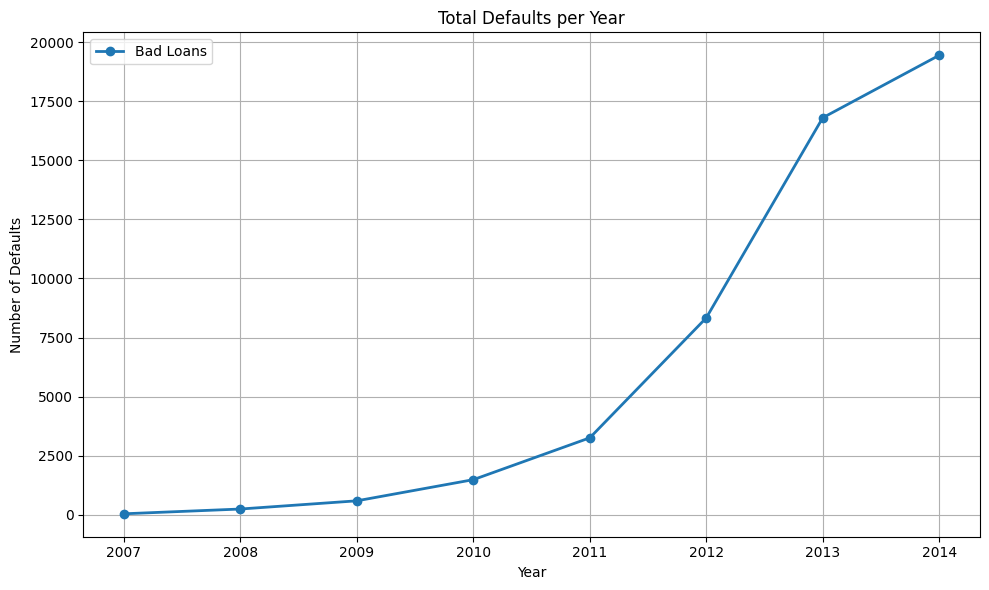

In [ ]:
print("\n" + "=" * 60)
print("TIME SERIES ANALYSIS: DEFAULT PER YEAR")
print("=" * 60)

import matplotlib.pyplot as plt
import pandas as pd

filt_data = df_clean.copy()
filt_data['issue_d'] = pd.to_datetime(filt_data['issue_d'], errors='coerce')

bad_loan = filt_data[filt_data['target'] == 0].copy()
bad_loan['year'] = bad_loan['issue_d'].dt.year
failures_per_year = bad_loan.groupby('year').size()
plt.figure(figsize=(10,6))

plt.plot(
    failures_per_year.index,
    failures_per_year.values,
    marker='o',
    linewidth=2,
    label='Bad Loans'
)

plt.title('Total Defaults per Year')
plt.xlabel('Year')
plt.ylabel('Number of Defaults')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


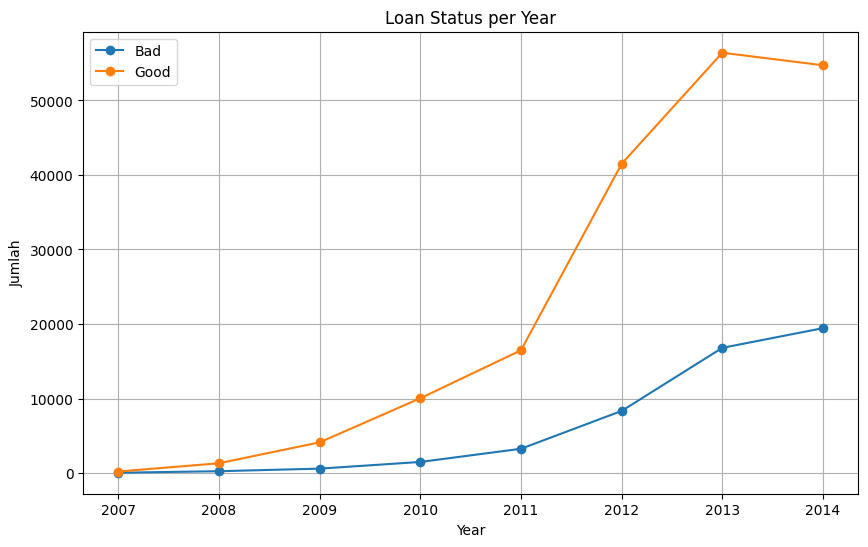

In [ ]:
# group semua loan
filt_data['year'] = filt_data['issue_d'].dt.year

yearly = filt_data.groupby(['year','target']).size().unstack()
yearly.columns = ['Bad', 'Good']
yearly.plot(figsize=(10,6), marker='o')

plt.title('Loan Status per Year')
plt.xlabel('Year')
plt.ylabel('Jumlah')
plt.grid(True)
plt.show()

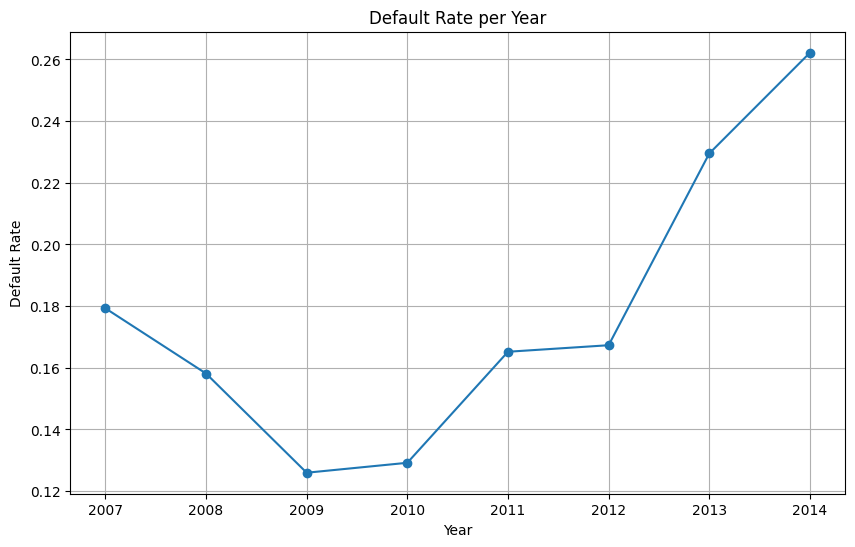

In [ ]:
#Default Rate % gagal bayar
yearly['total'] = yearly['Bad'] + yearly['Good']
yearly['default_rate'] = yearly['Bad'] / yearly['total']

plt.figure(figsize=(10,6))
plt.plot(yearly.index, yearly['default_rate'], marker='o')

plt.title('Default Rate per Year')
plt.xlabel('Year')
plt.ylabel('Default Rate')
plt.grid(True)

plt.show()

In [ ]:
print("\n" + "=" * 60)
print("DATA CLEANING MISSING VALUES")
print("=" * 60)

missing = filt_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Jumlah NULL per kolom:\n")
print(missing)

missing_pct = (filt_data.isnull().sum() / len(filt_data)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("\nPersentase NULL (%):\n")
print(missing_pct)

missing_df = pd.DataFrame({
    'missing_count': filt_data.isnull().sum(),
    'missing_pct': (filt_data.isnull().sum() / len(filt_data)) * 100
})

missing_df = missing_df[missing_df['missing_count'] > 0]
missing_df = missing_df.sort_values(by='missing_pct', ascending=False)

print("\nRingkasan Missing Values:\n")
print(missing_df)


DATA CLEANING MISSING VALUES
Jumlah NULL per kolom:

emp_length                    9122
last_pymnt_d                   364
payment_time                   364
revol_util                     191
collections_12_mths_ex_med      56
last_credit_pull_d              21
credit_history_length           21
dtype: int64

Persentase NULL (%):

emp_length                    3.882594
last_pymnt_d                  0.154929
payment_time                  0.154929
revol_util                    0.081295
collections_12_mths_ex_med    0.023835
last_credit_pull_d            0.008938
credit_history_length         0.008938
dtype: float64

Ringkasan Missing Values:

                            missing_count  missing_pct
emp_length                           9122     3.882594
last_pymnt_d                          364     0.154929
payment_time                          364     0.154929
revol_util                            191     0.081295
collections_12_mths_ex_med             56     0.023835
last_credit_pull_d 

In [ ]:
print("\n" + "=" * 60)
print("DATA CLEANING: HANDLE MISSING VALUES")
print("=" * 60)

df_model = filt_data.copy()

# 1. EMP_LENGTH (categorical)
df_model['emp_length'] = df_model['emp_length'].fillna('Unknown')

# 2. NUMERICAL IMPUTATION
# payment_time
df_model['payment_time'] = df_model['payment_time'].fillna(
    df_model['payment_time'].median()
)
# revol_util
df_model['revol_util'] = df_model['revol_util'].fillna(
    df_model['revol_util'].median()
)
# collections
df_model['collections_12_mths_ex_med'] = df_model['collections_12_mths_ex_med'].fillna(0)

# credit history
df_model['credit_history_length'] = df_model['credit_history_length'].fillna(
    df_model['credit_history_length'].median()
)
# 3. DROP KOLOM TIDAK PERLU
drop_cols = ['last_pymnt_d', 'last_credit_pull_d']
df_model = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

# 4. VALIDASI
print("\nSisa Missing Values:\n")
print(df_model.isnull().sum().sort_values(ascending=False).head(10))


DATA CLEANING: HANDLE MISSING VALUES

Sisa Missing Values:

loan_amnt              0
term                   0
int_rate               0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
issue_d                0
dtype: int64


In [ ]:
print("\n" + "=" * 60)
print("ENCODING: IDENTIFIKASI FITUR KATEGORIKAL")
print("=" * 60)

cat_features = df_model.select_dtypes(include=['object']).columns.tolist()

print("Jumlah fitur kategorikal:", len(cat_features))
print(cat_features)

print("\n" + "=" * 60)
print("UNIQUE VALUE PER FITUR")
print("=" * 60)

for col in cat_features:
    print(f"\n{col}")
    print(df_model[col].value_counts().head(10))


ENCODING: IDENTIFIKASI FITUR KATEGORIKAL
Jumlah fitur kategorikal: 10
['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'loan_status', 'pymnt_plan', 'purpose', 'initial_list_status']

UNIQUE VALUE PER FITUR

term
term
36 months    183262
60 months     51684
Name: count, dtype: int64

grade
grade
B    71636
C    60054
A    39344
D    37740
E    17375
F     7026
G     1771
Name: count, dtype: int64

sub_grade
sub_grade
B3    17243
B4    15981
C1    13828
B2    13819
B5    13270
C2    13162
C3    11722
B1    11323
A5    11023
C4    11012
Name: count, dtype: int64

emp_length
emp_length
10+ years    70469
2 years      21897
< 1 year     19414
3 years      19029
5 years      17052
1 year       15658
4 years      15117
6 years      14098
7 years      13302
8 years      10935
Name: count, dtype: int64

home_ownership
home_ownership
MORTGAGE    115513
RENT         99440
OWN          19808
OTHER          141
NONE            43
ANY              1
Name: count,

In [ ]:
print("\n" + "=" * 60)
print("ENCODING")
print("=" * 60)

df_encoded = df_model.copy()
term_mapping = {'36 months': 0, '60 months': 1}

home_ownership_mapping = {
    'OTHER': 0, 'NONE': 0, 'ANY': 0,
    'RENT': 1, 'MORTGAGE': 2, 'OWN': 3
}
grade_mapping = {
    'A': 6, 'B': 5, 'C': 4,
    'D': 3, 'E': 2, 'F': 1, 'G': 0
}
pymnt_plan_mapping = {'n': 1, 'y': 0}

for col in ['term', 'home_ownership', 'grade', 'pymnt_plan']:
    df_encoded[col] = df_encoded[col].astype(str).str.strip()

df_encoded['term'] = df_encoded['term'].map(term_mapping).fillna(-1).astype(int)
df_encoded['home_ownership'] = df_encoded['home_ownership'].map(home_ownership_mapping).fillna(-1).astype(int)
df_encoded['grade'] = df_encoded['grade'].map(grade_mapping).fillna(-1).astype(int)
df_encoded['pymnt_plan'] = df_encoded['pymnt_plan'].map(pymnt_plan_mapping).fillna(-1).astype(int)

# VALIDASI
print("\nHasil encoding:")
print(df_encoded[['term', 'home_ownership', 'grade', 'pymnt_plan']].head())

print("\nCek nilai unik setelah encoding:")
for col in ['term', 'home_ownership', 'grade', 'pymnt_plan']:
    print(f"\n{col}:")
    print(df_encoded[col].value_counts())

print("\nCek apakah ada nilai -1 (unknown category):")
for col in ['term', 'home_ownership', 'grade', 'pymnt_plan']:
    print(f"{col}: {(df_encoded[col] == -1).sum()}")



ENCODING

Hasil encoding:
   term  home_ownership  grade  pymnt_plan
0     0               1      5           1
1     1               1      4           1
2     0               1      4           1
3     0               1      4           1
5     0               1      6           1

Cek nilai unik setelah encoding:

term:
term
0    183262
1     51684
Name: count, dtype: int64

home_ownership:
home_ownership
2    115513
1     99440
3     19808
0       185
Name: count, dtype: int64

grade:
grade
5    71636
4    60054
6    39344
3    37740
2    17375
1     7026
0     1771
Name: count, dtype: int64

pymnt_plan:
pymnt_plan
1    234940
0         6
Name: count, dtype: int64

Cek apakah ada nilai -1 (unknown category):
term: 0
home_ownership: 0
grade: 0
pymnt_plan: 0


In [ ]:
print("\n" + "=" * 60)
print("DATA CLEANING: DROP LEAKAGE & NON-NUMERIC")
print("=" * 60)

# 1. KOLOM LEAKAGE (POST-LOAN)
leakage_cols = [
    'total_pymnt',
    'total_rec_int',
    'collection_recovery_fee',
    'last_pymnt_amnt', 'recoveries'
]
# 2. KOLOM NON-NUMERIK
non_numeric_cols = [
    'loan_status',
    'sub_grade', 'grade',
    'emp_length',
    'verification_status',
    'purpose',
    'initial_list_status'
]
# 3. KOLOM DATETIME
datetime_cols = [
    'issue_d',
    'earliest_cr_line'
]
# 4. KOLOM YEAR
year_cols = ['year']

cols_to_drop = leakage_cols + non_numeric_cols + datetime_cols + year_cols
df_final = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns])

# 7. SPLIT FEATURE & TARGET
X = df_final.drop(columns=['target'], errors='ignore')
y = df_final['target']

# 8. VALIDASI
print("\nJumlah fitur akhir:", X.shape[1])
print("\nFitur yang digunakan:")
print(X.columns.tolist())
print("\nTipe data:")
print(X.dtypes.value_counts())



DATA CLEANING: DROP LEAKAGE & NON-NUMERIC

Jumlah fitur akhir: 21

Fitur yang digunakan:
['loan_amnt', 'term', 'int_rate', 'home_ownership', 'annual_inc', 'pymnt_plan', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'total_rec_prncp', 'total_rec_late_fee', 'collections_12_mths_ex_med', 'acc_now_delinq', 'payment_time', 'credit_history_length']

Tipe data:
float64    16
int64       5
Name: count, dtype: int64


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234946 entries, 0 to 466283
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   234946 non-null  int64  
 1   term                        234946 non-null  int64  
 2   int_rate                    234946 non-null  float64
 3   home_ownership              234946 non-null  int64  
 4   annual_inc                  234946 non-null  float64
 5   pymnt_plan                  234946 non-null  int64  
 6   dti                         234946 non-null  float64
 7   delinq_2yrs                 234946 non-null  float64
 8   inq_last_6mths              234946 non-null  float64
 9   open_acc                    234946 non-null  float64
 10  pub_rec                     234946 non-null  float64
 11  revol_bal                   234946 non-null  int64  
 12  revol_util                  234946 non-null  float64
 13  total_acc          


HEATMAP KORELASI FITUR NUMERIK

Jumlah fitur numerik: 22
['loan_amnt', 'term', 'int_rate', 'home_ownership', 'annual_inc', 'pymnt_plan', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'total_rec_prncp', 'total_rec_late_fee', 'collections_12_mths_ex_med', 'acc_now_delinq', 'payment_time', 'credit_history_length', 'target']


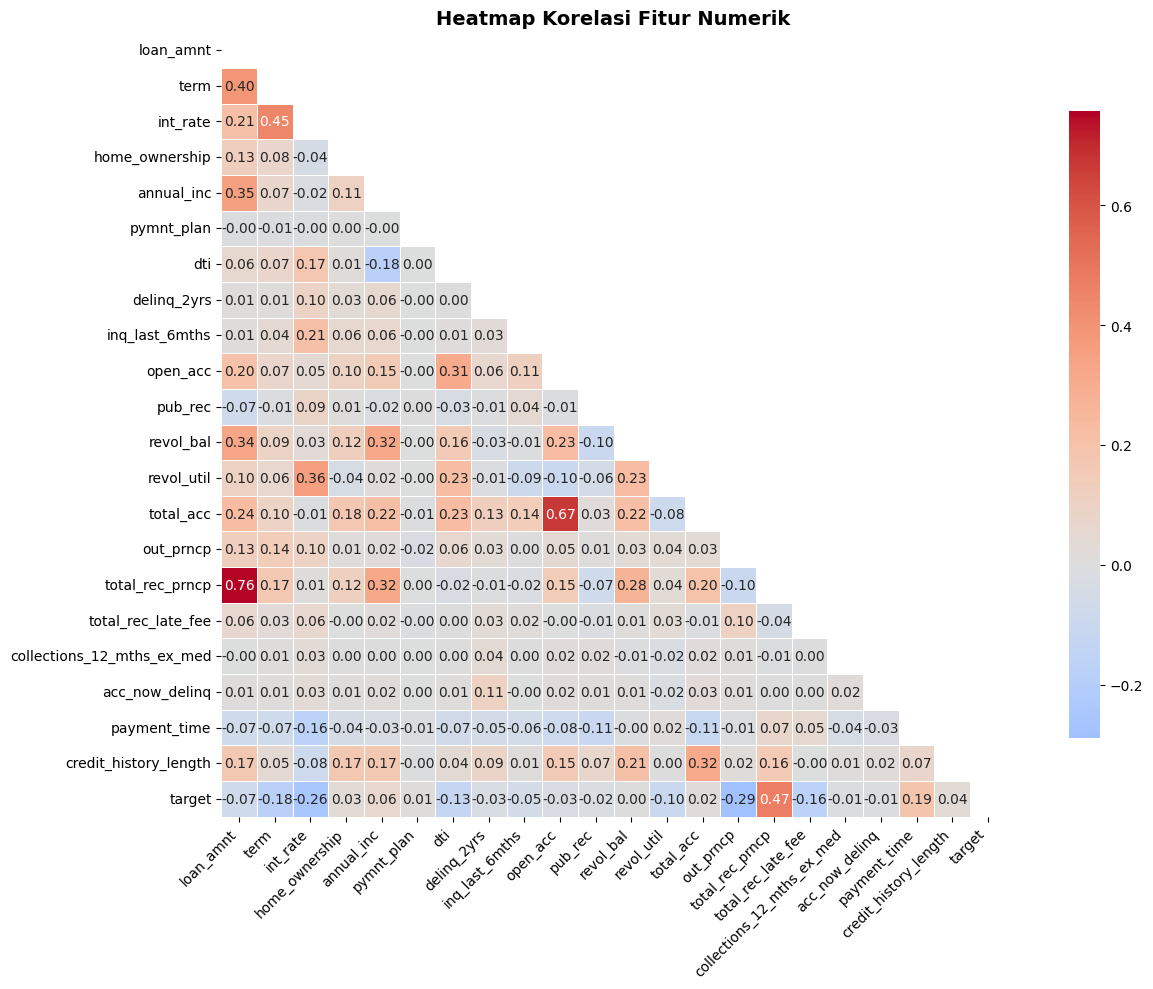

In [ ]:
print("\n" + "=" * 60)
print("HEATMAP KORELASI FITUR NUMERIK")
print("=" * 60)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

num_df = df_final.select_dtypes(include=['int64', 'float64', 'int32'])

print("\nJumlah fitur numerik:", num_df.shape[1])
print(num_df.columns.tolist())

corr_matrix = num_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()



MODELING: LOGISTIC REGRESSION
Fitur digunakan: ['loan_amnt', 'term', 'int_rate', 'home_ownership', 'annual_inc', 'pymnt_plan', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'total_rec_prncp', 'total_rec_late_fee', 'collections_12_mths_ex_med', 'acc_now_delinq', 'payment_time', 'credit_history_length']

Train size: (187956, 21)
Test size : (46990, 21)

Accuracy: 0.984507341987657

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96     10042
         1.0       0.99      0.99      0.99     36948

    accuracy                           0.98     46990
   macro avg       0.98      0.97      0.98     46990
weighted avg       0.98      0.98      0.98     46990



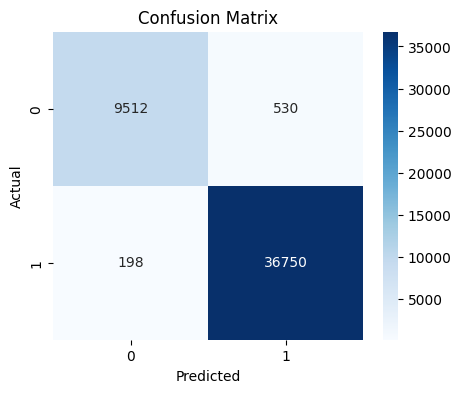


ROC AUC: 0.9958479032428851


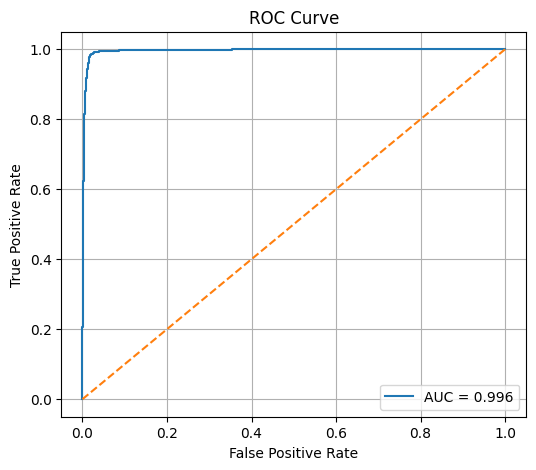

In [ ]:
print("\n" + "=" * 60)
print("MODELING: LOGISTIC REGRESSION")
print("=" * 60)

X = df_final.select_dtypes(include=['int64', 'float64']).drop(columns=['target'], errors='ignore')
y = df_final['target']

print("Fitur digunakan:", X.columns.tolist())
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size :", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC AUC
auc = roc_auc_score(y_test, y_prob)
print("\nROC AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()



MODEL 2: RANDOM FOREST

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     10042
         1.0       0.96      1.00      0.98     36948

    accuracy                           0.97     46990
   macro avg       0.98      0.93      0.95     46990
weighted avg       0.97      0.97      0.97     46990

ROC AUC: 0.9963619831459413

Top 10 Feature Importance - Random Forest:
total_rec_prncp       0.546896
loan_amnt             0.167336
out_prncp             0.115933
payment_time          0.050364
int_rate              0.034615
total_rec_late_fee    0.028056
term                  0.022698
revol_bal             0.008559
annual_inc            0.006890
dti                   0.006178
dtype: float64


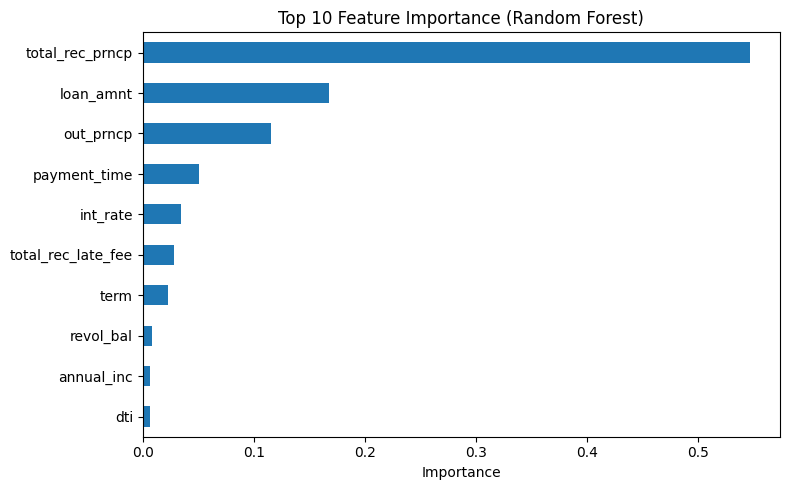

In [ ]:
print("\n" + "="*50)
print("MODEL 2: RANDOM FOREST")
print("="*50)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Evaluasi
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

# Feature importance
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_top10 = rf_importance.sort_values(ascending=False).head(10)
print("\nTop 10 Feature Importance - Random Forest:")
print(rf_top10)

# Plot
plt.figure(figsize=(8,5))
rf_top10.sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
